# Choosing and Using Solvers

`braincell.quad` ships a family of numerical integrators. This page shows how
to discover them, the two ways to apply them, and — most importantly — how to
choose one for the *stiff* dynamics that are typical of biophysical neurons.

In [1]:
import brainstate
import brainunit as u
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

import braincell
from braincell import DiffEqState, DiffEqModule

## The solver catalog

Integrators are grouped into categories. We can read them straight out of the
registry.

In [2]:
registry = braincell.quad.get_registry()

by_cat = {}
for name in registry.names():
    entry = registry.entry(name)
    by_cat.setdefault(entry.category, []).append(name)

for category, names in sorted(by_cat.items()):
    print(f"{category:>12} : {sorted(names)}")

    explicit : ['euler', 'heun2', 'heun3', 'midpoint', 'ralston2', 'ralston3', 'ralston4', 'rk2', 'rk3', 'rk4', 'ssprk3']
 exponential : ['exp_euler', 'exp_exp_euler', 'ind_exp_euler']
    implicit : ['backward_euler', 'cn_exp_euler', 'cn_rk4', 'implicit_euler', 'implicit_exp_euler', 'implicit_rk4', 'splitting']
   staggered : ['staggered']
     voltage : ['dhs_voltage']


The families, in rough order of how often you reach for them in neural
modeling:

| Category | Examples | Character |
| --- | --- | --- |
| `explicit` | `euler`, `midpoint`, `rk2/3/4`, `heun*`, `ralston*`, `ssprk3` | Classical Runge-Kutta. Cheap per step, high order available, but only *conditionally* stable — small `dt` required for stiff systems. |
| `exponential` | `exp_euler`, `ind_exp_euler`, `exp_exp_euler` | Treat the fast linear part exactly. Stable at large `dt` for the stiff gating dynamics of Hodgkin-Huxley neurons. The workhorse for point neurons. |
| `implicit` | `backward_euler`, `implicit_euler/rk4`, `cn_*`, `splitting` | Solve an implicit equation each step. Strong stability for very stiff problems at the cost of per-step linear solves. |
| `staggered`, `voltage` | `staggered`, `dhs_voltage` | Specialised schemes for multi-compartment cable equations. |

## Two ways to apply a solver

### 1. High-level: `solver=` on a cell

For a full neuron model you simply name the solver at construction. `braincell`
wires the lifecycle and stepping for you. Below is a minimal Hodgkin-Huxley
point neuron (the same recipe used in the single-compartment examples).

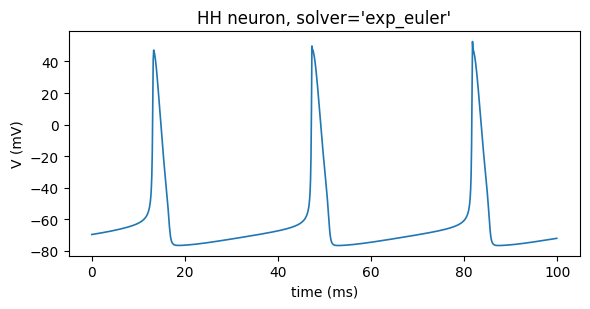

In [3]:
class HH(braincell.SingleCompartment):
    def __init__(self, size, solver="exp_euler"):
        super().__init__(size, solver=solver)
        self.na = braincell.ion.SodiumFixed(size, E=50. * u.mV)
        self.na.add(INa=braincell.channel.Na_HH1952(size))
        self.k = braincell.ion.PotassiumFixed(size, E=-77. * u.mV)
        self.k.add(IK=braincell.channel.K_HH1952(size))
        self.IL = braincell.channel.IL(size, E=-54.387 * u.mV,
                                       g_max=0.03 * (u.mS / u.cm ** 2))


def simulate(solver, dt=0.1, t_end=100.):
    neuron = HH(1, solver=solver)
    neuron.init_state()

    def step(t):
        with brainstate.environ.context(t=t):
            neuron.update(10. * u.nA / u.cm ** 2)   # constant drive
        return neuron.V.value

    with brainstate.environ.context(dt=dt * u.ms):
        times = u.math.arange(0. * u.ms, t_end * u.ms, brainstate.environ.get_dt())
        vs = brainstate.transform.for_loop(step, times)
    return np.asarray(times.to_decimal(u.ms)), np.asarray(u.math.squeeze(vs).to_decimal(u.mV))


t, v = simulate("exp_euler")
plt.figure(figsize=(6, 3.2))
plt.plot(t, v, lw=1.2)
plt.xlabel("time (ms)"); plt.ylabel("V (mV)")
plt.title("HH neuron, solver='exp_euler'")
plt.tight_layout(); plt.show()

### 2. Low-level: call the step function directly

When you drive a bare `DiffEqModule` yourself (as in the
[previous page](diffeq)), fetch the step function from the registry and call it
inside an `environ` context. This path works with the **generic** explicit
Runge-Kutta solvers, which make no assumption about the model being a neuron.

In [4]:
class Decay(brainstate.nn.Dynamics, DiffEqModule):
    def __init__(self, tau=10.0):
        super().__init__(in_size=1)
        self.tau = tau

    def init_state(self, *args):
        self.y = DiffEqState(jnp.ones(1))

    def compute_derivative(self, *args):
        self.y.derivative = -self.y.value / self.tau


def run_decay(solver_name, dt=0.1, t_end=50.0):
    model = Decay(tau=10.0)
    brainstate.nn.init_all_states(model)
    step = braincell.quad.get_integrator(solver_name)
    n = int(t_end / dt)
    with brainstate.environ.context(dt=dt):
        for i in range(n):
            with brainstate.environ.context(t=i * dt):
                step(model)
            last_t = (i + 1) * dt
    return last_t, float(model.y.value[0])

run_decay("rk4")

(50.0, 0.006737955845892429)

## Accuracy: order matters

On a smooth problem, a higher-order method reaches a given accuracy with far
fewer, larger steps. Here is the global error at $t=50$ for the decay problem
($y(50) = e^{-5}$) across three explicit schemes at the same `dt`.

In [5]:
exact = np.exp(-5.0)
print(f"{'solver':>10}  {'order':>5}  {'y(50)':>12}  {'abs error':>12}")
for name in ["euler", "midpoint", "rk4"]:
    order = braincell.quad.get_registry().entry(name).order
    _, y = run_decay(name, dt=0.5)
    print(f"{name:>10}  {order:>5}  {y:>12.3e}  {abs(y - exact):>12.3e}")

    solver  order         y(50)     abs error
     euler      1     5.921e-03     8.174e-04
  midpoint      2     6.753e-03     1.459e-05


       rk4      4     6.738e-03     9.306e-10


First-order Euler trails the fourth-order RK4 by several orders of
magnitude at the same step size. For smooth problems, prefer a higher-order
explicit method.

## Stability: why neurons need special solvers

Accuracy is not the whole story. Hodgkin-Huxley gating variables relax on a
sub-millisecond timescale while the spike itself plays out over milliseconds —
the system is **stiff**. Explicit methods are only conditionally stable: push
`dt` past a threshold and they blow up, no matter their order.

The demonstration below runs the *same* HH neuron at `dt = 0.1 ms` with an
exponential integrator and with explicit RK4.

exp_euler : max |V| = 76.6 mV | any NaN: False
rk4       : max |V| = 158.2 mV | any NaN: True


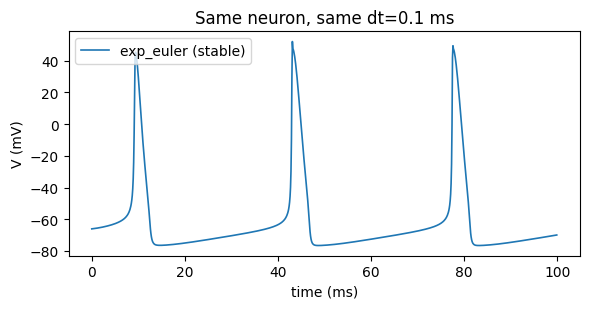

In [6]:
t_exp, v_exp = simulate("exp_euler", dt=0.1)
t_rk4, v_rk4 = simulate("rk4", dt=0.1)

print("exp_euler : max |V| =", f"{np.nanmax(np.abs(v_exp)):.1f} mV",
      "| any NaN:", bool(np.isnan(v_exp).any()))
print("rk4       : max |V| =", f"{np.nanmax(np.abs(v_rk4)):.1f} mV"
      if not np.isnan(v_rk4).all() else "nan",
      "| any NaN:", bool(np.isnan(v_rk4).any()))

plt.figure(figsize=(6, 3.2))
plt.plot(t_exp, v_exp, lw=1.2, label="exp_euler (stable)")
plt.xlabel("time (ms)"); plt.ylabel("V (mV)")
plt.title("Same neuron, same dt=0.1 ms")
plt.legend(); plt.tight_layout(); plt.show()

At `dt = 0.1 ms` `exp_euler` produces a clean spike train, while explicit
RK4 diverges to `NaN`. This is why exponential integrators (`exp_euler`, `ind_exp_euler`) are the
recommended choice for point neurons: they remain stable at the step sizes that
make large simulations affordable. (The `SingleCompartment` default is the
explicit `rk2`, so for stiff models you will usually want to pass `solver=...`
explicitly.)

For a side-by-side comparison of several integrators on a neuron — including how
the spike timing shifts between methods — see the worked example
[*Effects of Different Integration Methods on HH Neuron Dynamics*](../single_compartment/examples/integration_methods).

## Choosing a solver — rules of thumb

- **Point neurons (single compartment):** start with `exp_euler` or
  `ind_exp_euler`. They are stable at `dt = 0.1 ms` and accurate enough for
  spike-level fidelity.
- **Very stiff or near-equilibrium dynamics:** an `implicit` method
  (`backward_euler`, `implicit_exp_euler`) trades per-step cost for robustness.
- **Smooth, non-stiff sub-systems you drive yourself:** the explicit
  Runge-Kutta family (`rk4`, `midpoint`) is simplest and works on any
  `DiffEqModule`.
- **Multi-compartment cables:** see the `staggered` / `dhs_voltage` schemes,
  which exploit the tree structure of the morphology.

The [next page](advanced) covers mixing solvers across sub-systems, the
stochastic `diffusion` slot, and registering your own integrator.